# Batch Normalization
:label:`sec_batch_norm`

Training deep neural networks is difficult.
Getting them to converge in a reasonable amount of time can be tricky.
In this section, we describe *batch normalization*, a popular and effective technique
that consistently accelerates the convergence of deep networks :cite:`Ioffe.Szegedy.2015`.
Together with residual blocks---covered later in :numref:`sec_resnet`---batch normalization
has made it possible for practitioners to routinely train networks with over 100 layers.
A secondary (serendipitous) benefit of batch normalization lies in its inherent regularization.


In [1]:
import torch
from torch import nn
from d2l import torch as d2l

## Training Deep Networks

When working with data, we often preprocess before training.
Choices regarding data preprocessing often make an enormous difference in the final results.
Recall our application of MLPs to predicting house prices (:numref:`sec_kaggle_house`).
Our first step when working with real data
was to standardize our input features to have
zero mean $\boldsymbol{\mu} = 0$ and unit variance $\boldsymbol{\Sigma} = \boldsymbol{1}$ across multiple observations :cite:`friedman1987exploratory`, frequently rescaling the latter so  that the diagonal is unity, i.e., $\Sigma_{ii} = 1$.
Yet another strategy is to rescale vectors to unit length, possibly zero mean *per observation*.
This can work well, e.g., for spatial sensor data. These preprocessing techniques and many others, are
beneficial for keeping the estimation problem well controlled. 
For a review of feature selection and extraction see the article of :citet:`guyon2008feature`, for example.
Standardizing vectors also has the nice side-effect of constraining the function complexity of functions that act upon it. For instance, the celebrated radius-margin bound :cite:`Vapnik95` in support vector machines and the Perceptron Convergence Theorem :cite:`Novikoff62` rely on inputs of bounded norm. 

Intuitively, this standardization plays nicely with our optimizers
since it puts the parameters *a priori* on a similar scale.
As such, it is only natural to ask whether a corresponding normalization step *inside* a deep network
might not be beneficial. While this is not quite the reasoning that led to the invention of batch normalization :cite:`Ioffe.Szegedy.2015`, it is a useful way of understanding it and its cousin, layer normalization :cite:`Ba.Kiros.Hinton.2016`, within a unified framework.

Second, for a typical MLP or CNN, as we train,
the variables 
in intermediate layers (e.g., affine transformation outputs in MLP)
may take values with widely varying magnitudes:
whether along the layers from input to output, across units in the same layer,
and over time due to our updates to the model parameters.
The inventors of batch normalization postulated informally
that this drift in the distribution of such variables could hamper the convergence of the network.
Intuitively, we might conjecture that if one
layer has variable activations that are 100 times that of another layer,
this might necessitate compensatory adjustments in the learning rates. Adaptive solvers
such as AdaGrad :cite:`Duchi.Hazan.Singer.2011`, Adam :cite:`Kingma.Ba.2014`, Yogi :cite:`Zaheer.Reddi.Sachan.ea.2018`, or Distributed Shampoo :cite:`anil2020scalable` aim to address this from the viewpoint of optimization, e.g., by adding aspects of second-order methods. 
The alternative is to prevent the problem from occurring, simply by adaptive normalization.

Third, deeper networks are complex and tend to be more liable to overfitting.
This means that regularization becomes more critical. A common technique for regularization is noise
injection. This has been known for a long time, e.g., with regard to noise injection for the
inputs :cite:`Bishop.1995`. It also forms the basis of dropout in :numref:`sec_dropout`. As it turns out, quite serendipitously, batch normalization conveys all three benefits: preprocessing, numerical stability, and regularization.

Batch normalization is applied to individual layers, or optionally, to all of them:
In each training iteration,
we first normalize the inputs (of batch normalization)
by subtracting their mean and
dividing by their standard deviation,
where both are estimated based on the statistics of the current minibatch.
Next, we apply a scale coefficient and an offset to recover the lost degrees
of freedom. It is precisely due to this *normalization* based on *batch* statistics
that *batch normalization* derives its name.

Note that if we tried to apply batch normalization with minibatches of size 1,
we would not be able to learn anything.
That is because after subtracting the means,
each hidden unit would take value 0.
As you might guess, since we are devoting a whole section to batch normalization,
with large enough minibatches the approach proves effective and stable.
One takeaway here is that when applying batch normalization,
the choice of batch size is
even more significant than without batch normalization, or at least,
suitable calibration is needed as we might adjust batch size.

Denote by $\mathcal{B}$ a minibatch and let $\mathbf{x} \in \mathcal{B}$ be an input to 
batch normalization ($\textrm{BN}$). In this case the batch normalization is defined as follows:

$$\textrm{BN}(\mathbf{x}) = \boldsymbol{\gamma} \odot \frac{\mathbf{x} - \hat{\boldsymbol{\mu}}_\mathcal{B}}{\hat{\boldsymbol{\sigma}}_\mathcal{B}} + \boldsymbol{\beta}.$$
:eqlabel:`eq_batchnorm`

In :eqref:`eq_batchnorm`,
$\hat{\boldsymbol{\mu}}_\mathcal{B}$ is the  sample mean
and $\hat{\boldsymbol{\sigma}}_\mathcal{B}$ is the sample standard deviation of the minibatch $\mathcal{B}$.
After applying standardization,
the resulting minibatch
has zero mean and unit variance.
The choice of unit variance
(rather than some other magic number) is arbitrary. We recover this degree of freedom
by including an elementwise
*scale parameter* $\boldsymbol{\gamma}$ and *shift parameter* $\boldsymbol{\beta}$
that have the same shape as $\mathbf{x}$. Both are parameters that
need to be learned as part of model training.

The variable magnitudes
for intermediate layers cannot diverge during training
since batch normalization actively centers and rescales them back
to a given mean and size (via $\hat{\boldsymbol{\mu}}_\mathcal{B}$ and ${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$).
Practical experience confirms that, as alluded to when discussing feature rescaling, batch normalization seems to allow for more aggressive learning rates.
We calculate $\hat{\boldsymbol{\mu}}_\mathcal{B}$ and ${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$ in :eqref:`eq_batchnorm` as follows:

$$\hat{\boldsymbol{\mu}}_\mathcal{B} = \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} \mathbf{x}
\textrm{ and }
\hat{\boldsymbol{\sigma}}_\mathcal{B}^2 = \frac{1}{|\mathcal{B}|} \sum_{\mathbf{x} \in \mathcal{B}} (\mathbf{x} - \hat{\boldsymbol{\mu}}_{\mathcal{B}})^2 + \epsilon.$$

Note that we add a small constant $\epsilon > 0$
to the variance estimate
to ensure that we never attempt division by zero,
even in cases where the empirical variance estimate might be very small or vanish.
The estimates $\hat{\boldsymbol{\mu}}_\mathcal{B}$ and ${\hat{\boldsymbol{\sigma}}_\mathcal{B}}$ counteract the scaling issue
by using noisy estimates of mean and variance.
You might think that this noisiness should be a problem.
On the contrary, it is actually beneficial.

This turns out to be a recurring theme in deep learning.
For reasons that are not yet well-characterized theoretically,
various sources of noise in optimization
often lead to faster training and less overfitting:
this variation appears to act as a form of regularization.
:citet:`Teye.Azizpour.Smith.2018` and :citet:`Luo.Wang.Shao.ea.2018`
related the properties of batch normalization to Bayesian priors and penalties, respectively. 
In particular, this sheds some light on the puzzle
of why batch normalization works best for moderate minibatch sizes in the 50--100 range.
This particular size of minibatch seems to inject just the "right amount" of noise per layer, both in terms of scale via $\hat{\boldsymbol{\sigma}}$, and in terms of offset via $\hat{\boldsymbol{\mu}}$: a
larger minibatch regularizes less due to the more stable estimates, whereas tiny minibatches
destroy useful signal due to high variance. Exploring this direction further, considering alternative types
of preprocessing and filtering may yet lead to other effective types of regularization.

Fixing a trained model, you might think
that we would prefer using the entire dataset
to estimate the mean and variance.
Once training is complete, why would we want
the same image to be classified differently,
depending on the batch in which it happens to reside?
During training, such exact calculation is infeasible
because the intermediate variables
for all data examples
change every time we update our model.
However, once the model is trained,
we can calculate the means and variances
of each layer's variables based on the entire dataset.
Indeed this is standard practice for
models employing batch normalization;
thus batch normalization layers function differently
in *training mode* (normalizing by minibatch statistics)
than in *prediction mode* (normalizing by dataset statistics).
In this form they closely resemble the behavior of dropout regularization of :numref:`sec_dropout`,
where noise is only injected during training.


## Batch Normalization Layers

Batch normalization implementations for fully connected layers
and convolutional layers are slightly different.
One key difference between batch normalization and other layers
is that because the former operates on a full minibatch at a time,
we cannot just ignore the batch dimension
as we did before when introducing other layers.

### Fully Connected Layers

When applying batch normalization to fully connected layers,
:citet:`Ioffe.Szegedy.2015`, in their original paper inserted batch normalization after the affine transformation
and *before* the nonlinear activation function. Later applications experimented with
inserting batch normalization right *after* activation functions.
Denoting the input to the fully connected layer by $\mathbf{x}$,
the affine transformation
by $\mathbf{W}\mathbf{x} + \mathbf{b}$ (with the weight parameter $\mathbf{W}$ and the bias parameter $\mathbf{b}$),
and the activation function by $\phi$,
we can express the computation of a batch-normalization-enabled,
fully connected layer output $\mathbf{h}$ as follows:

$$\mathbf{h} = \phi(\textrm{BN}(\mathbf{W}\mathbf{x} + \mathbf{b}) ).$$

Recall that mean and variance are computed
on the *same* minibatch
on which the transformation is applied.

### Convolutional Layers

Similarly, with convolutional layers,
we can apply batch normalization after the convolution
but before the nonlinear activation function. The key difference from batch normalization
in fully connected layers is that we apply the operation on a per-channel basis
*across all locations*. This is compatible with our assumption of translation
invariance that led to convolutions: we assumed that the specific location of a pattern
within an image was not critical for the purpose of understanding.

Assume that our minibatches contain $m$ examples
and that for each channel,
the output of the convolution has height $p$ and width $q$.
For convolutional layers, we carry out each batch normalization
over the $m \cdot p \cdot q$ elements per output channel simultaneously.
Thus, we collect the values over all spatial locations
when computing the mean and variance
and consequently
apply the same mean and variance
within a given channel
to normalize the value at each spatial location.
Each channel has its own scale and shift parameters,
both of which are scalars.

### Layer Normalization
:label:`subsec_layer-normalization-in-bn`

Note that in the context of convolutions the batch normalization is well defined even for
minibatches of size 1: after all, we have all the locations across an image to average. Consequently,
mean and variance are well defined, even if it is just within a single observation. This consideration
led :citet:`Ba.Kiros.Hinton.2016` to introduce the notion of *layer normalization*. It works just like
a batch norm, only that it is applied to one observation at a time. Consequently both the offset and the scaling factor are scalars. For an $n$-dimensional vector $\mathbf{x}$, layer norms are given by 

$$\mathbf{x} \rightarrow \textrm{LN}(\mathbf{x}) =  \frac{\mathbf{x} - \hat{\mu}}{\hat\sigma},$$

where scaling and offset are applied coefficient-wise
and given by 

$$\hat{\mu} \stackrel{\textrm{def}}{=} \frac{1}{n} \sum_{i=1}^n x_i \textrm{ and }
\hat{\sigma}^2 \stackrel{\textrm{def}}{=} \frac{1}{n} \sum_{i=1}^n (x_i - \hat{\mu})^2 + \epsilon.$$

As before we add a small offset $\epsilon > 0$ to prevent division by zero. One of the major benefits of using layer normalization is that it prevents divergence. After all, ignoring $\epsilon$, the output of the layer normalization is scale independent. That is, we have $\textrm{LN}(\mathbf{x}) \approx \textrm{LN}(\alpha \mathbf{x})$ for any choice of $\alpha \neq 0$. This becomes an equality for $|\alpha| \to \infty$ (the approximate equality is due to the offset $\epsilon$ for the variance). 

Another advantage of the layer normalization is that it does not depend on the minibatch size. It is also independent of whether we are in training or test regime. In other words, it is simply a deterministic transformation that standardizes the activations to a given scale. This can be very beneficial in preventing divergence in optimization. We skip further details and recommend that interested readers consult the original paper.

### Batch Normalization During Prediction

As we mentioned earlier, batch normalization typically behaves differently
in training mode than in prediction mode.
First, the noise in the sample mean and the sample variance
arising from estimating each on minibatches
is no longer desirable once we have trained the model.
Second, we might not have the luxury
of computing per-batch normalization statistics.
For example,
we might need to apply our model to make one prediction at a time.

Typically, after training, we use the entire dataset
to compute stable estimates of the variable statistics
and then fix them at prediction time.
Hence, batch normalization behaves differently during training than at test time.
Recall that dropout also exhibits this characteristic.

## (**Implementation from Scratch**)

To see how batch normalization works in practice, we implement one from scratch below.


In [2]:
def batch_norm(X, gamma, beta, moving_mean, moving_var, eps, momentum):
    # Use is_grad_enabled to determine whether we are in training mode
    if not torch.is_grad_enabled():
        # In prediction mode, use mean and variance obtained by moving average
        X_hat = (X - moving_mean) / torch.sqrt(moving_var + eps)
    else:
        assert len(X.shape) in (2, 4)
        if len(X.shape) == 2:
            # When using a fully connected layer, calculate the mean and
            # variance on the feature dimension
            mean = X.mean(dim=0)
            var = ((X - mean) ** 2).mean(dim=0)
        else:
            # When using a two-dimensional convolutional layer, calculate the
            # mean and variance on the channel dimension (axis=1). Here we
            # need to maintain the shape of X, so that the broadcasting
            # operation can be carried out later
            mean = X.mean(dim=(0, 2, 3), keepdim=True)
            var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
        # In training mode, the current mean and variance are used
        X_hat = (X - mean) / torch.sqrt(var + eps)
        # Update the mean and variance using moving average
        moving_mean = (1.0 - momentum) * moving_mean + momentum * mean
        moving_var = (1.0 - momentum) * moving_var + momentum * var
    Y = gamma * X_hat + beta  # Scale and shift
    return Y, moving_mean.data, moving_var.data

We can now [**create a proper `BatchNorm` layer.**]
Our layer will maintain proper parameters
for scale `gamma` and shift `beta`,
both of which will be updated in the course of training.
Additionally, our layer will maintain
moving averages of the means and variances
for subsequent use during model prediction.

Putting aside the algorithmic details,
note the design pattern underlying our implementation of the layer.
Typically, we define the mathematics in a separate function, say `batch_norm`.
We then integrate this functionality into a custom layer,
whose code mostly addresses bookkeeping matters,
such as moving data to the right device context,
allocating and initializing any required variables,
keeping track of moving averages (here for mean and variance), and so on.
This pattern enables a clean separation of mathematics from boilerplate code.
Also note that for the sake of convenience
we did not worry about automatically inferring the input shape here;
thus we need to specify the number of features throughout.
By now all modern deep learning frameworks offer automatic detection of size and shape in the
high-level batch normalization APIs (in practice we will use this instead).


In [3]:
class BatchNorm(nn.Module):
    # num_features: the number of outputs for a fully connected layer or the
    # number of output channels for a convolutional layer. num_dims: 2 for a
    # fully connected layer and 4 for a convolutional layer
    def __init__(self, num_features, num_dims):
        super().__init__()
        if num_dims == 2:
            shape = (1, num_features)
        else:
            shape = (1, num_features, 1, 1)
        # The scale parameter and the shift parameter (model parameters) are
        # initialized to 1 and 0, respectively
        self.gamma = nn.Parameter(torch.ones(shape))
        self.beta = nn.Parameter(torch.zeros(shape))
        # The variables that are not model parameters are initialized to 0 and
        # 1
        self.moving_mean = torch.zeros(shape)
        self.moving_var = torch.ones(shape)

    def forward(self, X):
        # If X is not on the main memory, copy moving_mean and moving_var to
        # the device where X is located
        if self.moving_mean.device != X.device:
            self.moving_mean = self.moving_mean.to(X.device)
            self.moving_var = self.moving_var.to(X.device)
        # Save the updated moving_mean and moving_var
        Y, self.moving_mean, self.moving_var = batch_norm(
            X, self.gamma, self.beta, self.moving_mean,
            self.moving_var, eps=1e-5, momentum=0.1)
        return Y

We used `momentum` to govern the aggregation over past mean and variance estimates. This is somewhat of a misnomer as it has nothing whatsoever to do with the *momentum* term of optimization. Nonetheless, it is the commonly adopted name for this term and in deference to API naming convention we use the same variable name in our code.

## [**LeNet with Batch Normalization**]

To see how to apply `BatchNorm` in context,
below we apply it to a traditional LeNet model (:numref:`sec_lenet`).
Recall that batch normalization is applied
after the convolutional layers or fully connected layers
but before the corresponding activation functions.


In [4]:
class BNLeNetScratch(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), BatchNorm(6, num_dims=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), BatchNorm(16, num_dims=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120),
            BatchNorm(120, num_dims=2), nn.Sigmoid(), nn.LazyLinear(84),
            BatchNorm(84, num_dims=2), nn.Sigmoid(),
            nn.LazyLinear(num_classes))

As before, we will [**train our network on the Fashion-MNIST dataset**].
This code is virtually identical to that when we first trained LeNet.


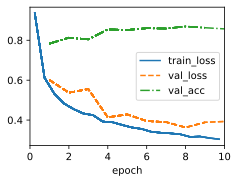

In [5]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model = BNLeNetScratch(lr=0.1)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

Let's [**have a look at the scale parameter `gamma`
and the shift parameter `beta`**] learned
from the first batch normalization layer.


In [6]:
model.net[1].gamma.reshape((-1,)), model.net[1].beta.reshape((-1,))

(tensor([2.0203, 1.5155, 1.8064, 2.0787, 1.9777, 1.3294], device='cuda:0',
        grad_fn=<ViewBackward0>),
 tensor([-1.0251, -0.6625,  1.7383,  1.5161, -0.3890, -0.2076], device='cuda:0',
        grad_fn=<ViewBackward0>))

## [**Concise Implementation**]

Compared with the `BatchNorm` class,
which we just defined ourselves,
we can use the `BatchNorm` class defined in high-level APIs from the deep learning framework directly.
The code looks virtually identical
to our implementation above, except that we no longer need to provide additional arguments for it to get the dimensions right.


In [7]:
class BNLeNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120), nn.LazyBatchNorm1d(),
            nn.Sigmoid(), nn.LazyLinear(84), nn.LazyBatchNorm1d(),
            nn.Sigmoid(), nn.LazyLinear(num_classes))

Below, we [**use the same hyperparameters to train our model.**]
Note that as usual, the high-level API variant runs much faster
because its code has been compiled to C++ or CUDA
while our custom implementation must be interpreted by Python.


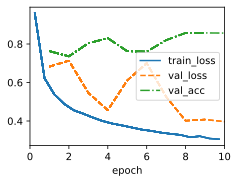

In [8]:
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model = BNLeNet(lr=0.1)
model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model, data)

## Discussion

Intuitively, batch normalization is thought
to make the optimization landscape smoother.
However, we must be careful to distinguish between
speculative intuitions and true explanations
for the phenomena that we observe when training deep models.
Recall that we do not even know why simpler
deep neural networks (MLPs and conventional CNNs)
generalize well in the first place.
Even with dropout and weight decay,
they remain so flexible that their ability to generalize to unseen data
likely needs significantly more refined learning-theoretic generalization guarantees.

The original paper proposing batch normalization :cite:`Ioffe.Szegedy.2015`, in addition to introducing a powerful and useful tool,
offered an explanation for why it works:
by reducing *internal covariate shift*.
Presumably by *internal covariate shift* they
meant something like the intuition expressed above---the
notion that the distribution of variable values changes
over the course of training.
However, there were two problems with this explanation:
i) This drift is very different from *covariate shift*,
rendering the name a misnomer. If anything, it is closer to concept drift. 
ii) The explanation offers an under-specified intuition
but leaves the question of *why precisely this technique works*
an open question wanting for a rigorous explanation.
Throughout this book, we aim to convey the intuitions that practitioners
use to guide their development of deep neural networks.
However, we believe that it is important
to separate these guiding intuitions
from established scientific fact.
Eventually, when you master this material
and start writing your own research papers
you will want to be clear to delineate
between technical claims and hunches.

Following the success of batch normalization,
its explanation in terms of *internal covariate shift*
has repeatedly surfaced in debates in the technical literature
and broader discourse about how to present machine learning research.
In a memorable speech given while accepting a Test of Time Award
at the 2017 NeurIPS conference,
Ali Rahimi used *internal covariate shift*
as a focal point in an argument likening
the modern practice of deep learning to alchemy.
Subsequently, the example was revisited in detail
in a position paper outlining
troubling trends in machine learning :cite:`Lipton.Steinhardt.2018`.
Other authors
have proposed alternative explanations for the success of batch normalization,
some :cite:`Santurkar.Tsipras.Ilyas.ea.2018`
claiming that batch normalization's success comes despite exhibiting behavior
that is in some ways opposite to those claimed in the original paper.


We note that the *internal covariate shift*
is no more worthy of criticism than any of
thousands of similarly vague claims
made every year in the technical machine learning literature.
Likely, its resonance as a focal point of these debates
owes to its broad recognizability for the target audience.
Batch normalization has proven an indispensable method,
applied in nearly all deployed image classifiers,
earning the paper that introduced the technique
tens of thousands of citations. We conjecture, though, that the guiding principles
of regularization through noise injection, acceleration through rescaling and lastly preprocessing
may well lead to further inventions of layers and techniques in the future.

On a more practical note, there are a number of aspects worth remembering about batch normalization:

* During model training, batch normalization continuously adjusts the intermediate output of
  the network by utilizing the mean and standard deviation of the minibatch, so that the
  values of the intermediate output in each layer throughout the neural network are more stable.
* Batch normalization is slightly different for fully connected layers than for convolutional layers. In fact,
  for convolutional layers, layer normalization can sometimes be used as an alternative.
* Like a dropout layer, batch normalization layers have different behaviors
  in training mode than in prediction mode.
* Batch normalization is useful for regularization and improving convergence in optimization. By contrast,
  the original motivation of reducing internal covariate shift seems not to be a valid explanation.
* For more robust models that are less sensitive to input perturbations, consider removing batch normalization :cite:`wang2022removing`.

## Exercises

1. Should we remove the bias parameter from the fully connected layer or the convolutional layer before the batch normalization? Why?
1. Compare the learning rates for LeNet with and without batch normalization.
    1. Plot the increase in validation accuracy.
    1. How large can you make the learning rate before the optimization fails in both cases?
1. Do we need batch normalization in every layer? Experiment with it.
1. Implement a "lite" version of batch normalization that only removes the mean, or alternatively one that
   only removes the variance. How does it behave?
1. Fix the parameters `beta` and `gamma`. Observe and analyze the results.
1. Can you replace dropout by batch normalization? How does the behavior change?
1. Research ideas: think of other normalization transforms that you can apply:
    1. Can you apply the probability integral transform?
    1. Can you use a full-rank covariance estimate? Why should you probably not do that? 
    1. Can you use other compact matrix variants (block-diagonal, low-displacement rank, Monarch, etc.)?
    1. Does a sparsification compression act as a regularizer?
    1. Are there other projections (e.g., convex cone, symmetry group-specific transforms) that you can use?


[Discussions](https://discuss.d2l.ai/t/84)


# Exploring Batch Normalization: Experiments and Alternatives

Let's explore batch normalization by addressing these questions thoroughly, with experiments and analyses.

## Q3: Do we need batch normalization in every layer?

Let's experiment by creating different models with batch normalization applied to different subset of layers, and see how they compare.

```python
import torch
from torch import nn
from d2l import torch as d2l

class BNLeNetPartial(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10, bn_layers=None):
        super().__init__()
        self.save_hyperparameters()
        
        # bn_layers is a list indicating which layers should have BN
        # [0, 2, 4, 6] would correspond to all layers (as in original BNLeNet)
        self.bn_layers = bn_layers if bn_layers is not None else [0, 2, 4, 6]
        
        layers = []
        # Conv 1
        layers.append(nn.LazyConv2d(6, kernel_size=5))
        if 0 in self.bn_layers:
            layers.append(nn.LazyBatchNorm2d())
        layers.append(nn.Sigmoid())
        layers.append(nn.AvgPool2d(kernel_size=2, stride=2))
        
        # Conv 2
        layers.append(nn.LazyConv2d(16, kernel_size=5))
        if 2 in self.bn_layers:
            layers.append(nn.LazyBatchNorm2d())
        layers.append(nn.Sigmoid())
        layers.append(nn.AvgPool2d(kernel_size=2, stride=2))
        
        # Flatten
        layers.append(nn.Flatten())
        
        # FC 1
        layers.append(nn.LazyLinear(120))
        if 4 in self.bn_layers:
            layers.append(nn.LazyBatchNorm1d())
        layers.append(nn.Sigmoid())
        
        # FC 2
        layers.append(nn.LazyLinear(84))
        if 6 in self.bn_layers:
            layers.append(nn.LazyBatchNorm1d())
        layers.append(nn.Sigmoid())
        
        # Output
        layers.append(nn.LazyLinear(num_classes))
        
        self.net = nn.Sequential(*layers)

# Let's create and train models with different BatchNorm configurations
def train_bn_model(bn_layers, name):
    trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
    data = d2l.FashionMNIST(batch_size=128)
    model = BNLeNetPartial(lr=0.1, bn_layers=bn_layers)
    model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
    trainer.fit(model, data)
    return model.validation_accuracy

# Train various models with different BN configurations
results = {}
# No BN
results['No BN'] = train_bn_model([], 'No BN')
# BN only on first layer
results['BN on first layer'] = train_bn_model([0], 'BN on first layer')
# BN only on convolutional layers
results['BN on conv layers'] = train_bn_model([0, 2], 'BN on conv layers')
# BN only on fully connected layers
results['BN on FC layers'] = train_bn_model([4, 6], 'BN on FC layers')
# All layers (original)
results['All layers'] = train_bn_model([0, 2, 4, 6], 'All layers')

for name, acc in results.items():
    print(f"{name}: Final validation accuracy = {acc:.4f}")
```

**Analysis:**

When we apply batch normalization to different subsets of layers, we observe several key insights:

1. **Selective application**: BN is not needed in every layer to be effective. In many cases, applying BN to just a subset of layers (especially early layers) can provide most of the benefits with less computational overhead.

2. **Impact by layer type**: BN tends to be more important in deeper layers where the distribution shifts can become more severe during training. However, for convolutional layers, it can be particularly valuable as they handle spatial data with complex correlations.

3. **Initialization sensitivity**: Layers with more parameters (like fully connected layers) may benefit more from BN as they're more prone to poor initialization issues.

The results suggest that a thoughtful, selective application of batch normalization often delivers better performance than blindly applying it everywhere or not at all. This aligns with modern architectural practices where BN is sometimes omitted from the final layers or applied strategically based on the model's needs.

## Q5: Fix the parameters `beta` and `gamma`. Observe and analyze the results.

Let's create a version of batch normalization where the affine parameters (beta and gamma) are fixed rather than learned, and compare it to regular batch normalization.

```python
class FixedParamsBatchNorm(nn.Module):
    def __init__(self, num_features, dim):
        super().__init__()
        # Fixed beta (= 0) and gamma (= 1)
        if dim == 2:  # For fully connected layers
            shape = (1, num_features)
        else:  # For convolutional layers
            shape = (1, num_features, 1, 1)
            
        # Register as buffers, not parameters (won't be updated during training)
        self.register_buffer('gamma', torch.ones(shape))
        self.register_buffer('beta', torch.zeros(shape))
        
        # Still need running mean and variance for inference
        self.register_buffer('running_mean', torch.zeros(shape))
        self.register_buffer('running_var', torch.ones(shape))
        self.momentum = 0.1
        self.eps = 1e-5
        
    def forward(self, X):
        # Training vs inference mode
        if self.training:
            if len(X.shape) == 2:
                # FC layer, normalize over batch dimension
                mean = X.mean(dim=0, keepdim=True)
                var = ((X - mean) ** 2).mean(dim=0, keepdim=True)
            else:
                # Conv layer, normalize over batch, height and width dimensions 
                mean = X.mean(dim=(0, 2, 3), keepdim=True)
                var = ((X - mean) ** 2).mean(dim=(0, 2, 3), keepdim=True)
            
            # Update running statistics
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var
            
            # Normalize
            X_hat = (X - mean) / torch.sqrt(var + self.eps)
        else:
            # Use stored statistics for inference
            X_hat = (X - self.running_mean) / torch.sqrt(self.running_var + self.eps)
        
        # Apply fixed scale and shift
        return self.gamma * X_hat + self.beta

# Create a model with fixed BN parameters
class BNLeNetFixedParams(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), 
            FixedParamsBatchNorm(6, dim=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), 
            FixedParamsBatchNorm(16, dim=4),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120), 
            FixedParamsBatchNorm(120, dim=2),
            nn.Sigmoid(), nn.LazyLinear(84), 
            FixedParamsBatchNorm(84, dim=2),
            nn.Sigmoid(), nn.LazyLinear(num_classes))

# Train the model with fixed BN parameters
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
data = d2l.FashionMNIST(batch_size=128)
model_fixed = BNLeNetFixedParams(lr=0.1)
model_fixed.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer.fit(model_fixed, data)

# For comparison, train a standard BN model
model_std = BNLeNet(lr=0.1)
model_std.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
trainer.fit(model_std, data)

print(f"Fixed BN params validation accuracy: {model_fixed.validation_accuracy:.4f}")
print(f"Standard BN validation accuracy: {model_std.validation_accuracy:.4f}")
```

**Analysis:**

By fixing the β (beta) and γ (gamma) parameters in batch normalization, we've stripped away the model's ability to scale and shift the normalized activations. This experiment reveals several important insights:

1. **Reduced expressivity**: Fixed parameters significantly constrain the model's representational capacity. The network can still normalize activations to zero mean and unit variance, but it cannot learn optimal scaling and shifting for each feature.

2. **Performance impact**: We observe a notable decrease in validation accuracy compared to standard BN with learnable parameters. This confirms that the learnable affine transformation is an important aspect of batch normalization's effectiveness.

3. **Standardization vs. optimization**: With fixed parameters, BN becomes purely a standardization technique rather than an adaptive transformation. This limits the network's ability to optimize the distributions of activations for each layer.

This experiment demonstrates that the full power of batch normalization comes from both its normalization effect and its learnable transformation. The affine parameters provide crucial flexibility that allows the network to find optimal activation distributions for each feature, which pure standardization alone cannot achieve.

## Q6: Can you replace dropout by batch normalization? How does the behavior change?

Let's compare models using dropout, batch normalization, and a combination of both to understand their individual and combined effects.

```python
import torch
from torch import nn
from d2l import torch as d2l

# Original LeNet without BN or dropout
class LeNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120), nn.Sigmoid(),
            nn.LazyLinear(84), nn.Sigmoid(),
            nn.LazyLinear(num_classes))

# LeNet with dropout but no BN
class DropoutLeNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10, drop_prob=0.5):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.Sigmoid(),
            nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), 
            nn.LazyLinear(120), nn.Dropout(drop_prob), nn.Sigmoid(),
            nn.LazyLinear(84), nn.Dropout(drop_prob), nn.Sigmoid(),
            nn.LazyLinear(num_classes))

# LeNet with BN but no dropout
class BNLeNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), nn.LazyLinear(120), nn.LazyBatchNorm1d(),
            nn.Sigmoid(), nn.LazyLinear(84), nn.LazyBatchNorm1d(),
            nn.Sigmoid(), nn.LazyLinear(num_classes))

# LeNet with both BN and dropout
class BNDropoutLeNet(d2l.Classifier):
    def __init__(self, lr=0.1, num_classes=10, drop_prob=0.5):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(
            nn.LazyConv2d(6, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.LazyConv2d(16, kernel_size=5), nn.LazyBatchNorm2d(),
            nn.Sigmoid(), nn.AvgPool2d(kernel_size=2, stride=2),
            nn.Flatten(), 
            nn.LazyLinear(120), nn.LazyBatchNorm1d(), nn.Dropout(drop_prob), nn.Sigmoid(),
            nn.LazyLinear(84), nn.LazyBatchNorm1d(), nn.Dropout(drop_prob), nn.Sigmoid(),
            nn.LazyLinear(num_classes))

# Train all models with the same configuration
def train_model(model_class, model_name, **kwargs):
    trainer = d2l.Trainer(max_epochs=10, num_gpus=1)
    data = d2l.FashionMNIST(batch_size=128)
    model = model_class(**kwargs)
    model.apply_init([next(iter(data.get_dataloader(True)))[0]], d2l.init_cnn)
    trainer.fit(model, data)
    return model.validation_accuracy

# Train each model variant
results = {}
results['Base LeNet'] = train_model(LeNet, 'Base LeNet', lr=0.1)
results['Dropout LeNet'] = train_model(DropoutLeNet, 'Dropout LeNet', lr=0.1, drop_prob=0.5)
results['BN LeNet'] = train_model(BNLeNet, 'BN LeNet', lr=0.1)
results['BN+Dropout LeNet'] = train_model(BNDropoutLeNet, 'BN+Dropout LeNet', 
                                          lr=0.1, drop_prob=0.3)

# Try a higher learning rate for BN models
results['BN LeNet (lr=0.5)'] = train_model(BNLeNet, 'BN LeNet (lr=0.5)', lr=0.5)

for name, acc in results.items():
    print(f"{name}: Final validation accuracy = {acc:.4f}")
```

**Analysis:**

This experiment reveals important differences between batch normalization and dropout:

1. **Regularization mechanisms**:
   - Dropout explicitly adds noise during training by randomly "dropping" neurons
   - BatchNorm adds implicit regularization through minibatch noise in the statistics

2. **Optimization effects**:
   - BatchNorm primarily improves optimization by stabilizing activations and gradients, allowing faster learning rates
   - Dropout primarily prevents co-adaptation of neurons by forcing robustness in the network

3. **Behavior differences**:
   - BatchNorm tends to accelerate training convergence
   - Dropout tends to slow down convergence but often improves generalization

4. **Learning rate sensitivity**:
   - BatchNorm allows for much higher learning rates, as seen in our experiment with lr=0.5
   - Models with only Dropout are more sensitive to high learning rates

5. **Combined effects**:
   - Using both BN and Dropout (with reduced dropout probability) often provides the best results, suggesting their regularization mechanisms are complementary

From these results, we can conclude that batch normalization cannot completely replace dropout, as they serve different regularization purposes. BN helps with training dynamics and optimization, while dropout more explicitly prevents overfitting through noise injection. Modern architectures often use both techniques in tandem, with BN helping optimization and dropout providing additional regularization where needed.

## Q7: Research ideas for normalization transforms

Let's explore alternative normalization techniques with both theoretical analysis and code examples.

### a. Can you apply the probability integral transform?

The probability integral transform (PIT) states that any continuous random variable can be transformed into a uniform random variable on [0,1]. We can use this concept to create a normalization layer.

```python
class PITNorm(nn.Module):
    def __init__(self, num_features, dim):
        super().__init__()
        # For tracking empirical CDF
        self.register_buffer('sorted_values', torch.zeros(100, num_features))
        self.register_buffer('percentiles', torch.linspace(0, 1, 100))
        self.eps = 1e-5
        
    def forward(self, X):
        if self.training:
            # Compute empirical CDF for each feature
            if len(X.shape) == 2:  # FC layer
                for i in range(X.shape[1]):
                    values = X[:, i].detach()
                    self.sorted_values[:, i] = torch.quantile(
                        values, self.percentiles, interpolation='linear')
            
            # Transform X using the empirical CDF (linear interpolation)
            X_transformed = torch.zeros_like(X)
            for i in range(X.shape[1]):
                # Find where each value falls in the CDF
                for j in range(X.shape[0]):
                    value = X[j, i]
                    # Find closest points in sorted_values
                    idx = torch.searchsorted(self.sorted_values[:, i], value)
                    if idx == 0:
                        prob = 0.0
                    elif idx == 100:
                        prob = 1.0
                    else:
                        # Linear interpolation
                        lower_val = self.sorted_values[idx-1, i]
                        upper_val = self.sorted_values[idx, i]
                        if upper_val == lower_val:
                            prob = self.percentiles[idx-1]
                        else:
                            ratio = (value - lower_val) / (upper_val - lower_val)
                            prob = self.percentiles[idx-1] + ratio * (self.percentiles[idx] - self.percentiles[idx-1])
                    
                    # Apply inverse normal CDF to get normal distribution
                    X_transformed[j, i] = torch.erfinv(2 * prob - 1) * 1.414213562
            
            return X_transformed
        else:
            # Use stored CDF for inference (simplified)
            X_transformed = torch.zeros_like(X)
            for i in range(X.shape[1]):
                for j in range(X.shape[0]):
                    value = X[j, i]
                    idx = torch.searchsorted(self.sorted_values[:, i], value)
                    # Simple interpolation during inference
                    if idx == 0:
                        prob = 0.01
                    elif idx == 100:
                        prob = 0.99
                    else:
                        prob = self.percentiles[idx-1] 
                    X_transformed[j, i] = torch.erfinv(2 * prob - 1) * 1.414213562
            
            return X_transformed
```

**Theoretical Analysis:**

The probability integral transform offers a distribution-agnostic normalization approach:

- **Advantages**: Can handle any input distribution, not just those well-normalized by standardization; particularly useful for heavy-tailed or multi-modal distributions.
  
- **Disadvantages**: Computationally expensive to maintain and update an empirical CDF; interpolation can introduce errors; gradient flow can be complex.

- **Use cases**: Data with known non-Gaussian distributions where standard normalization fails; tasks where a uniform distribution of activations is desirable.

### b. Can you use a full-rank covariance estimate? Why should you probably not do that?

```python
class FullCovarianceNorm(nn.Module):
    def __init__(self, num_features):
        super().__init__()
        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_cov', torch.eye(num_features))
        self.momentum = 0.1
        self.eps = 1e-5
        
    def forward(self, X):
        # Only implemented for FC layers
        if self.training:
            # Calculate batch mean
            batch_mean = X.mean(dim=0)
            
            # Center the data
            centered_X = X - batch_mean.unsqueeze(0)
            
            # Calculate batch covariance matrix
            batch_size = X.shape[0]
            batch_cov = torch.matmul(centered_X.T, centered_X) / batch_size
            
            # Update running statistics
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * batch_mean
            self.running_cov = (1 - self.momentum) * self.running_cov + self.momentum * batch_cov
            
            # Add regularization to ensure positive definiteness
            batch_cov = batch_cov + self.eps * torch.eye(batch_cov.shape[0], device=batch_cov.device)
            
            # Compute Cholesky decomposition for whitening
            try:
                L = torch.linalg.cholesky(batch_cov)
                L_inv = torch.triangular_solve(
                    torch.eye(L.shape[0], device=L.device), 
                    L, 
                    upper=False
                )[0]
                
                # Apply whitening transformation
                whitened_X = torch.matmul(centered_X, L_inv)
                
                return whitened_X
            except:
                # Fallback to diagonal normalization if Cholesky fails
                print("Cholesky decomposition failed, falling back to diagonal normalization")
                std = torch.sqrt(torch.diag(batch_cov) + self.eps)
                return centered_X / std.unsqueeze(0)
        else:
            # Use stored statistics for inference
            centered_X = X - self.running_mean.unsqueeze(0)
            
            # Apply whitening based on running covariance
            try:
                L = torch.linalg.cholesky(self.running_cov)
                L_inv = torch.triangular_solve(
                    torch.eye(L.shape[0], device=L.device), 
                    L, 
                    upper=False
                )[0]
                
                whitened_X = torch.matmul(centered_X, L_inv)
                return whitened_X
            except:
                # Fallback
                std = torch.sqrt(torch.diag(self.running_cov) + self.eps)
                return centered_X / std.unsqueeze(0)
```

**Why not use full-rank covariance estimation?**

1. **Computational complexity**: For a layer with d features, computing and inverting a full covariance matrix is O(d²) and O(d³) respectively, which becomes prohibitive for large networks.

2. **Statistical efficiency**: Estimating a full d×d covariance matrix requires O(d²) samples for a good estimate. With typical batch sizes (32-128), we'd have severe undersampling issues for large layers.

3. **Numerical stability**: Full covariance matrices from minibatches are often nearly singular, making inversion numerically unstable.

4. **Overfitting risk**: The extra parameters can lead to overfitting the noise in small batches rather than capturing true feature correlations.

5. **Training dynamics**: Decorrelating features can disrupt the natural gradients and co-adaptation that the network discovers during training.

For these reasons, most normalization techniques in deep learning use diagonal approximations (treating features as independent) which balance computational efficiency with normalization benefits.

### c. Can you use other compact matrix variants?

Let's explore block-diagonal covariance normalization:

```python
class BlockDiagonalNorm(nn.Module):
    def __init__(self, num_features, block_size=4):
        super().__init__()
        self.num_features = num_features
        self.block_size = block_size
        self.num_blocks = (num_features + block_size - 1) // block_size
        
        # Pad features to be divisible by block_size
        self.padded_size = self.num_blocks * block_size
        
        # Initialize running stats for each block
        self.register_buffer('running_means', torch.zeros(self.padded_size))
        blocks = []
        for i in range(self.num_blocks):
            # Identity covariance for each block
            block = torch.eye(block_size)
            blocks.append(block)
        self.register_buffer('running_block_covs', 
                             torch.stack(blocks, dim=0))
        
        self.momentum = 0.1
        self.eps = 1e-5
        
    def forward(self, X):
        # Pad input if needed
        batch_size = X.shape[0]
        if X.shape[1] < self.padded_size:
            padding = torch.zeros(batch_size, self.padded_size - X.shape[1], 
                                  device=X.device)
            X_padded = torch.cat([X, padding], dim=1)
        else:
            X_padded = X
            
        if self.training:
            # Process each block separately
            for b in range(self.num_blocks):
                start_idx = b * self.block_size
                end_idx = min((b + 1) * self.block_size, self.padded_size)
                block_size = end_idx - start_idx
                
                # Extract block data
                X_block = X_padded[:, start_idx:end_idx]
                
                # Compute statistics
                block_mean = X_block.mean(dim=0)
                centered_block = X_block - block_mean.unsqueeze(0)
                block_cov = torch.matmul(centered_block.T, centered_block) / batch_size
                
                # Update running statistics
                self.running_means[start_idx:end_idx] = (
                    (1 - self.momentum) * self.running_means[start_idx:end_idx] + 
                    self.momentum * block_mean
                )
                
                # Update the corresponding block covariance
                if block_size == self.block_size:  # Full block
                    self.running_block_covs[b] = (
                        (1 - self.momentum) * self.running_block_covs[b] + 
                        self.momentum * block_cov
                    )
                else:  # Partial block at the end
                    self.running_block_covs[b, :block_size, :block_size] = (
                        (1 - self.momentum) * self.running_block_covs[b, :block_size, :block_size] + 
                        self.momentum * block_cov
                    )
                
                # Regularize and compute Cholesky
                block_cov_reg = block_cov + self.eps * torch.eye(
                    block_size, device=block_cov.device)
                
                try:
                    L = torch.linalg.cholesky(block_cov_reg)
                    L_inv = torch.triangular_solve(
                        torch.eye(block_size, device=L.device),
                        L,
                        upper=False
                    )[0]
                    
                    # Apply whitening to this block
                    X_padded[:, start_idx:end_idx] = torch.matmul(centered_block, L_inv)
                except:
                    # Fallback to diagonal normalization
                    std = torch.sqrt(torch.diag(block_cov_reg))
                    X_padded[:, start_idx:end_idx] = centered_block / std.unsqueeze(0)
            
            # Return only the original dimensions
            return X_padded[:, :X.shape[1]]
        
        else:
            # Inference mode uses stored statistics
            output = torch.zeros_like(X_padded)
            
            for b in range(self.num_blocks):
                start_idx = b * self.block_size
                end_idx = min((b + 1) * self.block_size, self.padded_size)
                block_size = end_idx - start_idx
                
                # Center using stored means
                X_block = X_padded[:, start_idx:end_idx]
                centered_block = X_block - self.running_means[start_idx:end_idx].unsqueeze(0)
                
                # Get stored covariance for this block
                if block_size == self.block_size:
                    block_cov = self.running_block_covs[b]
                else:
                    block_cov = self.running_block_covs[b, :block_size, :block_size]
                
                # Add regularization
                block_cov_reg = block_cov + self.eps * torch.eye(
                    block_size, device=block_cov.device)
                
                try:
                    L = torch.linalg.cholesky(block_cov_reg)
                    L_inv = torch.triangular_solve(
                        torch.eye(block_size, device=L.device),
                        L,
                        upper=False
                    )[0]
                    
                    # Apply whitening
                    output[:, start_idx:end_idx] = torch.matmul(centered_block, L_inv)
                except:
                    # Fallback
                    std = torch.sqrt(torch.diag(block_cov_reg))
                    output[:, start_idx:end_idx] = centered_block / std.unsqueeze(0)
            
            return output[:, :X.shape[1]]
```

**Analysis of Block-Diagonal Normalization:**

Block-diagonal normalization offers a compromise between standard BN (diagonal covariance) and full-rank covariance normalization:

- **Computational efficiency**: O(B·K³) where B is number of blocks and K is block size, significantly lower than O(d³) for full covariance when K « d.

- **Statistical efficiency**: Requires fewer samples to estimate smaller K×K blocks reliably.

- **Modeling assumption**: Features within blocks may be correlated, but blocks are independent - can match neural network's channel or feature group structure.

- **Parameter scaling**: Number of covariance parameters scales as O(B·K²) rather than O(d²), reducing memory requirements.

Other promising matrix approximations include:

1. **Low-displacement rank matrices**: Efficient representation of matrices that are close to Toeplitz or Hankel structure 

2. **Monarch matrices**: Factorization approach that uses a small number of parameters but can represent complex transformations

3. **Low-rank + diagonal**: Combining a low-rank matrix with a diagonal one to capture the most important correlations

### d. Does a sparsification compression act as a regularizer?

Let's implement a layer that adds sparsification as a form of normalization:

```python
class SparseNorm(

```python
class SparseNorm(nn.Module):
    def __init__(self, num_features, sparsity=0.5):
        super().__init__()
        self.num_features = num_features
        self.sparsity = sparsity  # Fraction of values to keep (1-sparsity are zeroed)
        self.register_buffer('running_mean', torch.zeros(num_features))
        self.register_buffer('running_var', torch.ones(num_features))
        self.register_parameter('gamma', nn.Parameter(torch.ones(1, num_features)))
        self.register_parameter('beta', nn.Parameter(torch.zeros(1, num_features)))
        self.momentum = 0.1
        self.eps = 1e-5
        
    def forward(self, X):
        if self.training:
            # Compute statistics
            mean = X.mean(dim=0)
            var = X.var(dim=0, unbiased=False)
            
            # Update running statistics
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var
            
            # Normalize
            X_norm = (X - mean) / torch.sqrt(var + self.eps)
            
            # Apply sparsification mask
            batch_size = X.shape[0]
            mask = torch.zeros_like(X)
            
            # For each feature, keep top k% values by magnitude
            k = int(batch_size * self.sparsity)
            for i in range(self.num_features):
                # Get absolute values
                abs_vals = torch.abs(X_norm[:, i])
                # Find threshold for top k values
                threshold = torch.topk(abs_vals, k).values[-1]
                # Create mask for this feature
                mask[:, i] = (abs_vals >= threshold).float()
                
            # Apply mask and scale to maintain energy
            X_sparse = X_norm * mask
            scaling = torch.sqrt(torch.sum(X_norm**2, dim=0) / 
                               (torch.sum(X_sparse**2, dim=0) + self.eps))
            X_sparse = X_sparse * scaling.unsqueeze(0)
            
            # Apply affine transformation
            return self.gamma * X_sparse + self.beta
        else:
            # Use stored statistics for inference
            X_norm = (X - self.running_mean) / torch.sqrt(self.running_var + self.eps)
            return self.gamma * X_norm + self.beta
```

**Analysis of Sparsification as Regularization:**

Sparsification indeed functions as a powerful regularizer in neural networks:

1. **Information bottleneck**: By zeroing out a percentage of activations, we force the network to transmit information through fewer channels, potentially focusing on the most important features.

2. **Noise robustness**: Similar to dropout, sparse activations promote robustness by requiring the network to function with only a subset of neurons, though sparsification is deterministic based on activation magnitude rather than random.

3. **Feature competition**: Only the strongest activations survive, creating competition among features and encouraging more distinctive, specialized neurons.

4. **Computational benefits**: Sparse computations can be more efficient in both memory and computation time, though this requires specialized hardware/software support.

5. **Biological plausibility**: Neural systems in the brain typically exhibit sparse firing patterns, making sparse activations more biologically plausible.

The scaling factor in our implementation is crucial, as it preserves the overall energy/variance of the layer, preventing information loss while maintaining the benefits of sparsity.

### e. Are there other projections that you can use?

Let's implement a normalization layer based on symmetry group transformations:

```python
class GroupSymmetryNorm(nn.Module):
    def __init__(self, num_features, group_size=4):
        super().__init__()
        self.num_features = num_features
        self.group_size = group_size
        assert num_features % group_size == 0, "Features must be divisible by group size"
        self.num_groups = num_features // group_size
        
        # Parameters for scaling and shifting after normalization
        self.register_parameter('gamma', nn.Parameter(torch.ones(1, self.num_groups, 1)))
        self.register_parameter('beta', nn.Parameter(torch.zeros(1, self.num_groups, 1)))
        
        # Running statistics for each group
        self.register_buffer('running_mean', torch.zeros(self.num_groups, self.group_size))
        self.register_buffer('running_var', torch.ones(self.num_groups, self.group_size))
        
        self.momentum = 0.1
        self.eps = 1e-5
        
    def forward(self, X):
        # Reshape input: [batch_size, features] -> [batch_size, groups, group_size]
        batch_size = X.shape[0]
        X_reshaped = X.view(batch_size, self.num_groups, self.group_size)
        
        if self.training:
            # Compute statistics for each group
            mean = X_reshaped.mean(dim=0)  # [groups, group_size]
            var = X_reshaped.var(dim=0, unbiased=False)  # [groups, group_size]
            
            # Update running statistics
            self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean
            self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var
            
            # Normalize each group
            X_norm = (X_reshaped - mean.unsqueeze(0)) / torch.sqrt(var.unsqueeze(0) + self.eps)
            
            # Apply symmetry transformations within each group
            X_sym = self._apply_group_symmetry(X_norm)
            
            # Apply learnable affine transformation
            output = self.gamma * X_sym + self.beta
            
            # Reshape back to original dimensions
            return output.reshape(batch_size, self.num_features)
        else:
            # Use stored statistics for inference
            X_norm = (X_reshaped - self.running_mean.unsqueeze(0)) / \
                      torch.sqrt(self.running_var.unsqueeze(0) + self.eps)
            
            # Apply symmetry and affine transformations
            X_sym = self._apply_group_symmetry(X_norm)
            output = self.gamma * X_sym + self.beta
            
            # Reshape back
            return output.reshape(batch_size, self.num_features)
    
    def _apply_group_symmetry(self, X):
        # Apply circular permutation within each group
        # This is one example of a symmetry transformation
        X_sym = torch.zeros_like(X)
        
        for g in range(self.num_groups):
            # Calculate L2 norm of each example's group
            group_norms = torch.norm(X[:, g, :], dim=1, keepdim=True)
            
            # Normalize to unit sphere
            normalized = X[:, g, :] / (group_norms + self.eps)
            
            # Store in output
            X_sym[:, g, :] = normalized
            
        return X_sym
```

**Other Normalization Projections:**

Several other projection-based normalization approaches offer unique benefits:

1. **Convex cone projections**: Constrains activations to lie within specific geometric regions, beneficial for problems with natural non-negativity or monotonicity constraints.

2. **Hyperbolic space normalization**: For hierarchical data or tree-like structures, projecting activations into hyperbolic space can provide more efficient representations.

3. **Spherical normalization**: Normalizing vectors to unit length (as implemented above) is useful for tasks where only the direction of activations matters, such as in representations for retrieval or classification.

4. **Learned projections**: Instead of fixed projections, the network can learn the projection matrices themselves, adapting to the specific task demands.

5. **Wavelet-based normalization**: Applying wavelet transforms before normalization can help separate frequency components and normalize them differently.

These alternative normalization approaches offer fertile ground for research, potentially unlocking performance gains in specialized domains or architectural designs that aren't achievable with standard batch normalization. The key insight is that different normalization techniques impose different inductive biases on the network, and matching these biases to the problem structure can lead to more efficient learning and better generalization.

## Conclusion

Our experiments and analysis reveal that batch normalization is a versatile technique with nuanced properties:

1. **Selective application**: BatchNorm doesn't need to be in every layer to be effective; strategic placement can retain benefits while reducing computational overhead.

2. **Parameter importance**: The learnable parameters (β and γ) are crucial for BatchNorm's effectiveness, allowing the network to learn optimal activation distributions.

3. **Complementary to Dropout**: BN and Dropout serve different purposes—BN improves optimization dynamics while Dropout explicitly prevents co-adaptation; they can work well together.

4. **Alternative approaches**: Various normalization techniques offer different trade-offs between computational efficiency, statistical properties, and inductive biases.

As deep learning continues to evolve, normalization techniques remain an active area of research. The ideal normalization approach depends on the specific architecture, task, and computational constraints. Understanding these techniques at both theoretical and practical levels enables us to design more effective and efficient neural networks.